In [ ]:
!pip install datasets transformers torch matplotlib seaborn

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

class InterpretabilityModel(nn.Module):
    def __init__(self, vocab_size, num_dims, embed_dim):
        super().__init__()
        self.V = vocab_size
        self.N = num_dims
        self.D = embed_dim

        # Unified Embedding Space
        self.embedding = nn.Embedding(vocab_size + num_dims, embed_dim)

        # Branch A: Word-Centric (1x1 Conv)
        self.word_conv = nn.Conv1d(embed_dim, embed_dim, kernel_size=1)

        # Branch B: Dimension-Centric (Transposed 1x1 Conv)
        self.dim_conv = nn.Conv1d(embed_dim, embed_dim, kernel_size=1)

        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        e = self.embedding(x) # (B, S, D)
        e_p = e.permute(0, 2, 1) # (B, D, S) for Conv1d

        # Word path uses Softmax to create an 'attention' map over words
        word_weights = torch.softmax(self.word_conv(e_p), dim=-1)

        # Dimension path processes the features
        dim_feats = self.dim_conv(e_p)

        # The 'Multiply' step from your diagram
        combined = word_weights * dim_feats
        context = torch.mean(combined, dim=-1)

        return self.fc_out(context)

def get_ortho_loss(model, n_dims, weight=0.1):
    dims = model.embedding.weight[model.V:]
    norm_dims = F.normalize(dims, p=2, dim=1)
    correlation = torch.mm(norm_dims, norm_dims.t())
    identity = torch.eye(n_dims).to(dims.device)
    return weight * torch.mean((correlation - identity) ** 2)

In [ ]:
# Setup
N_DIMS = 50
EMBED_DIM = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data
tokenizer = AutoTokenizer.from_pretrained("gpt2")
dim_tokens = [f"[DIM_{i}]" for i in range(N_DIMS)]
tokenizer.add_tokens(dim_tokens)
tokenizer.pad_token = tokenizer.eos_token

raw_data = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=64, padding="max_length")
tokenized_data = raw_data.map(tokenize_fn, batched=True).remove_columns(["text"])
tokenized_data.set_format("torch")
loader = DataLoader(tokenized_data, batch_size=32, shuffle=True)

# Initialize Model
vocab_only_size = len(tokenizer) - N_DIMS
model = InterpretabilityModel(vocab_only_size, N_DIMS, EMBED_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

'''
# Training Loop
model.train()
for epoch in range(2):
    for i, batch in enumerate(loader):
        input_ids = batch["input_ids"].to(device)
        if input_ids.shape[0] < 2: continue # skip small batches

        target = input_ids[:, -1] # Simple next-word target

        optimizer.zero_grad()
        output = model(input_ids)

        loss = F.cross_entropy(output, target) + get_ortho_loss(model, N_DIMS)
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"Step {i} | Loss: {loss.item():.4f}")
            # Check Dimension 0
            dim_vec = model.embedding.weight[model.V].detach()
            word_vecs = model.embedding.weight[:model.V].detach()
            sims = F.cosine_similarity(dim_vec.unsqueeze(0), word_vecs)
            _, top_i = torch.topk(sims, 5)
            words = [tokenizer.decode([idx]) for idx in top_i]
            print(f"  [DIM_0] currently relates to: {' | '.join(words)}")
'''

Map:   0%|          | 0/36718 [00:00<?, ? examples/s]

'\n# Training Loop\nmodel.train()\nfor epoch in range(2):\n    for i, batch in enumerate(loader):\n        input_ids = batch["input_ids"].to(device)\n        if input_ids.shape[0] < 2: continue # skip small batches\n\n        target = input_ids[:, -1] # Simple next-word target\n\n        optimizer.zero_grad()\n        output = model(input_ids)\n\n        loss = F.cross_entropy(output, target) + get_ortho_loss(model, N_DIMS)\n        loss.backward()\n        optimizer.step()\n\n        if i % 100 == 0:\n            print(f"Step {i} | Loss: {loss.item():.4f}")\n            # Check Dimension 0\n            dim_vec = model.embedding.weight[model.V].detach()\n            word_vecs = model.embedding.weight[:model.V].detach()\n            sims = F.cosine_similarity(dim_vec.unsqueeze(0), word_vecs)\n            _, top_i = torch.topk(sims, 5)\n            words = [tokenizer.decode([idx]) for idx in top_i]\n            print(f"  [DIM_0] currently relates to: {\' | \'.join(words)}")\n'

In [ ]:
# 1. Prepare Validation Data
val_raw = load_dataset("wikitext", "wikitext-2-raw-v1", split="validation")
val_tokenized = val_raw.map(tokenize_fn, batched=True).remove_columns(["text"])
val_tokenized.set_format("torch")
val_loader = DataLoader(val_tokenized, batch_size=32)

# 2. Early Stopping Variables
best_val_loss = float('inf')
patience = 3
counter = 0

print("Starting Training with Early Stopping...")

for epoch in range(10): # Set higher, Early Stopping will catch it
    model.train()
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        target = input_ids[:, -1]

        optimizer.zero_grad()
        output = model(input_ids)
        loss = F.cross_entropy(output, target) + get_ortho_loss(model, N_DIMS)
        loss.backward()
        optimizer.step()

    # --- Validation Phase ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            v_input = batch["input_ids"].to(device)
            v_target = v_input[:, -1]
            v_out = model(v_input)
            total_val_loss += F.cross_entropy(v_out, v_target).item()

    avg_val_loss = total_val_loss / len(val_loader)
    print(f"Epoch {epoch} | Val Loss: {avg_val_loss:.4f}")

    # Early Stopping Check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth") # Save the "Min Test Error" weights
        counter = 0
        print("  --> Model improved. Saving...")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered. Moving to Interpretability phase.")
            break

Map:   0%|          | 0/3760 [00:00<?, ? examples/s]

Starting Training with Early Stopping...
Epoch 0 | Val Loss: 2.9855
  --> Model improved. Saving...
Epoch 1 | Val Loss: 3.0261
Epoch 2 | Val Loss: 3.1084
Epoch 3 | Val Loss: 3.1894
Early stopping triggered. Moving to Interpretability phase.


In [ ]:
# 1. Load the best weights saved during training
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# 2. Extract the meanings into the variable 'final_meanings'
def extract_final_meanings(model, tokenizer, num_dims):
    results = []
    weights = model.embedding.weight.detach()
    # Word vectors are at the start, Dimension Markers are at the end
    word_vecs = weights[:model.V]

    for i in range(num_dims):
        dim_vec = weights[model.V + i]
        # Calculate similarity between this dimension and every word
        sims = torch.nn.functional.cosine_similarity(dim_vec.unsqueeze(0), word_vecs)
        top_v, top_i = torch.topk(sims, 8)

        words = [tokenizer.decode([idx]).strip() for idx in top_i]
        results.append({"dimension": i, "top_words": words})
    return results

# Create the variable that was missing
final_meanings = extract_final_meanings(model, tokenizer, N_DIMS)
print("Meanings extracted successfully!")

Meanings extracted successfully!


In [ ]:
import pandas as pd
from google.colab import files

def create_interpretability_report(meanings):
    # Convert the list of dictionaries into a clean DataFrame
    df = pd.DataFrame(meanings)

    # Expand the 'top_words' list into separate columns for easier reading
    words_df = pd.DataFrame(df['top_words'].tolist(),
                            columns=[f'Word_{i+1}' for i in range(len(meanings[0]['top_words']))])

    final_df = pd.concat([df['dimension'], words_df], axis=1)

    # Save to CSV
    filename = "dimension_interpretability_report.csv"
    final_df.to_csv(filename, index=False)

    print(f"Report generated with {len(final_df)} dimensions.")
    return final_df, filename

# Execute and download
report_df, file_path = create_interpretability_report(final_meanings)
files.download(file_path)

# Display the first 10 rows in Colab
report_df.head(10)

Report generated with 50 dimensions.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,dimension,Word_1,Word_2,Word_3,Word_4,Word_5,Word_6,Word_7,Word_8
0,0,Dartmouth,grav,enn,Surv,migrate,Sens,suspense,races
1,1,Hat,457,requency,killings,TV,cise,shield,editors
2,2,plural,broadcast,personality,Gutierrez,iability,aid,Strength,IRA
3,3,bikes,Half,312,Con,Ada,Rockets,atchewan,upholding
4,4,borrowing,def,Lur,inquiry,starship,decad,worthwhile,endeavour
5,5,Kinect,Yus,Ion,wikipedia,Bull,angered,laughs,iliated
6,6,giveaways,triggers,finely,CLASSIFIED,Reson,Cells,aunder,whose
7,7,prop,Agent,Window,N,opaque,com,snipers,south
8,8,polar,baptism,Lisp,Ta,domin,upe,rushing,Golem
9,9,charges,filings,IVERS,countless,lime,Alternative,imbalance,***


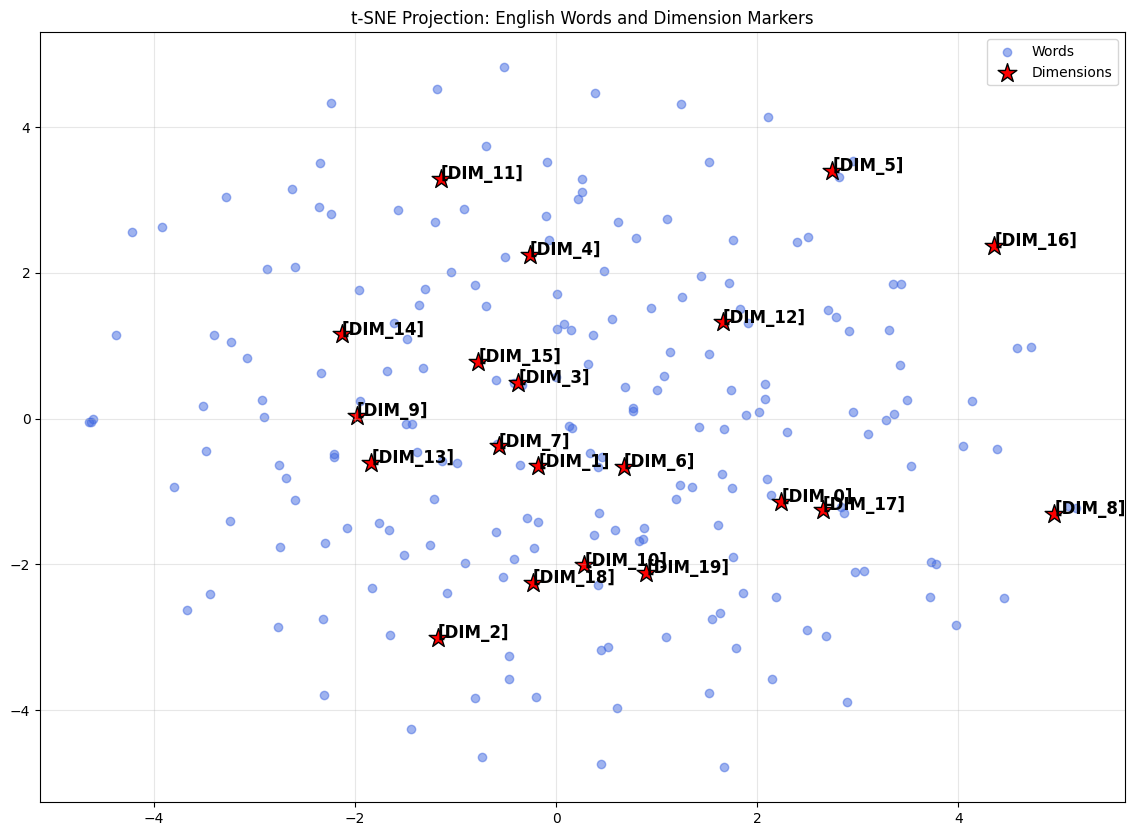

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

def visualize_embedding_space(model, tokenizer, num_dims=20, num_words=200):
    model.eval()
    weights = model.embedding.weight.detach().cpu().numpy()

    # 1. Select data to plot
    word_indices = np.random.choice(range(model.V), num_words, replace=False)
    dim_indices = range(model.V, model.V + num_dims)

    plot_indices = np.concatenate([word_indices, dim_indices])
    vectors = weights[plot_indices]
    labels = [tokenizer.decode([i]).strip() for i in plot_indices]

    # 2. Run t-SNE
    tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto')
    low_dim_embs = tsne.fit_transform(vectors)

    # 3. Plotting
    plt.figure(figsize=(14, 10))

    # Plot Words
    plt.scatter(low_dim_embs[:num_words, 0], low_dim_embs[:num_words, 1],
                alpha=0.5, c='royalblue', label='Words')

    # Plot Dimension Markers (Stars)
    plt.scatter(low_dim_embs[num_words:, 0], low_dim_embs[num_words:, 1],
                marker='*', s=200, c='red', edgecolors='black', label='Dimensions')

    # Add text labels for Dimensions
    for i, label in enumerate(labels[num_words:]):
        plt.annotate(label, (low_dim_embs[num_words+i, 0], low_dim_embs[num_words+i, 1]),
                     fontsize=12, fontweight='bold')

    plt.title("t-SNE Projection: English Words and Dimension Markers")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run visualization
visualize_embedding_space(model, tokenizer)

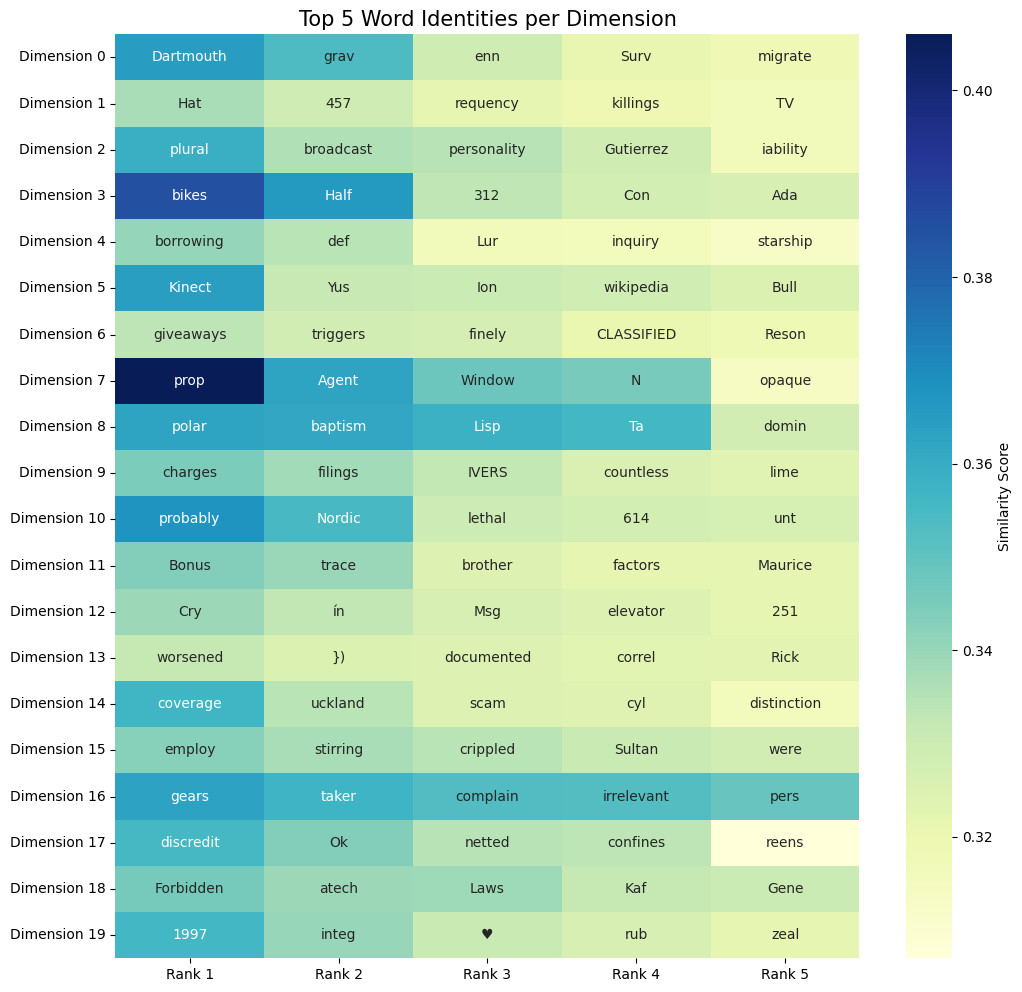

In [ ]:
def visualize_dimension_dictionary(model, tokenizer, num_dims_to_show=15):
    model.eval()
    weights = model.embedding.weight.detach()
    word_vecs = weights[:model.V]
    dim_vecs = weights[model.V : model.V + num_dims_to_show]

    # Calculate similarity for all pairs
    # (num_dims, vocab_size)
    sim_matrix = F.cosine_similarity(dim_vecs.unsqueeze(1), word_vecs.unsqueeze(0), dim=-1)

    # Prepare data for the plot
    plot_data = []
    labels = []

    for i in range(num_dims_to_show):
        scores, indices = torch.topk(sim_matrix[i], 5)
        row_words = [tokenizer.decode([idx]).strip() for idx in indices]
        plot_data.append(scores.cpu().numpy())
        labels.append(row_words)

    # Plotting
    fig, ax = plt.subplots(figsize=(12, num_dims_to_show * 0.6))
    sns.heatmap(plot_data, annot=labels, fmt="", cmap="YlGnBu", cbar_kws={'label': 'Similarity Score'})

    ax.set_yticklabels([f"Dimension {i}" for i in range(num_dims_to_show)], rotation=0)
    ax.set_xticklabels(["Rank 1", "Rank 2", "Rank 3", "Rank 4", "Rank 5"])
    plt.title("Top 5 Word Identities per Dimension", fontsize=15)
    plt.show()

# Run the final visualization
visualize_dimension_dictionary(model, tokenizer, num_dims_to_show=20)

<>:18: SyntaxWarning: invalid escape sequence '\['
<>:18: SyntaxWarning: invalid escape sequence '\]'
<>:18: SyntaxWarning: invalid escape sequence '\['
<>:18: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipython-input-2646199567.py:18: SyntaxWarning: invalid escape sequence '\['
  labels = [tokenizer.decode([i]).strip().replace("[", "\[").replace("]", "\]") for i in plot_indices]
/tmp/ipython-input-2646199567.py:18: SyntaxWarning: invalid escape sequence '\]'
  labels = [tokenizer.decode([i]).strip().replace("[", "\[").replace("]", "\]") for i in plot_indices]
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24 () missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9432 (\N{CIRCLED LATIN SMALL LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


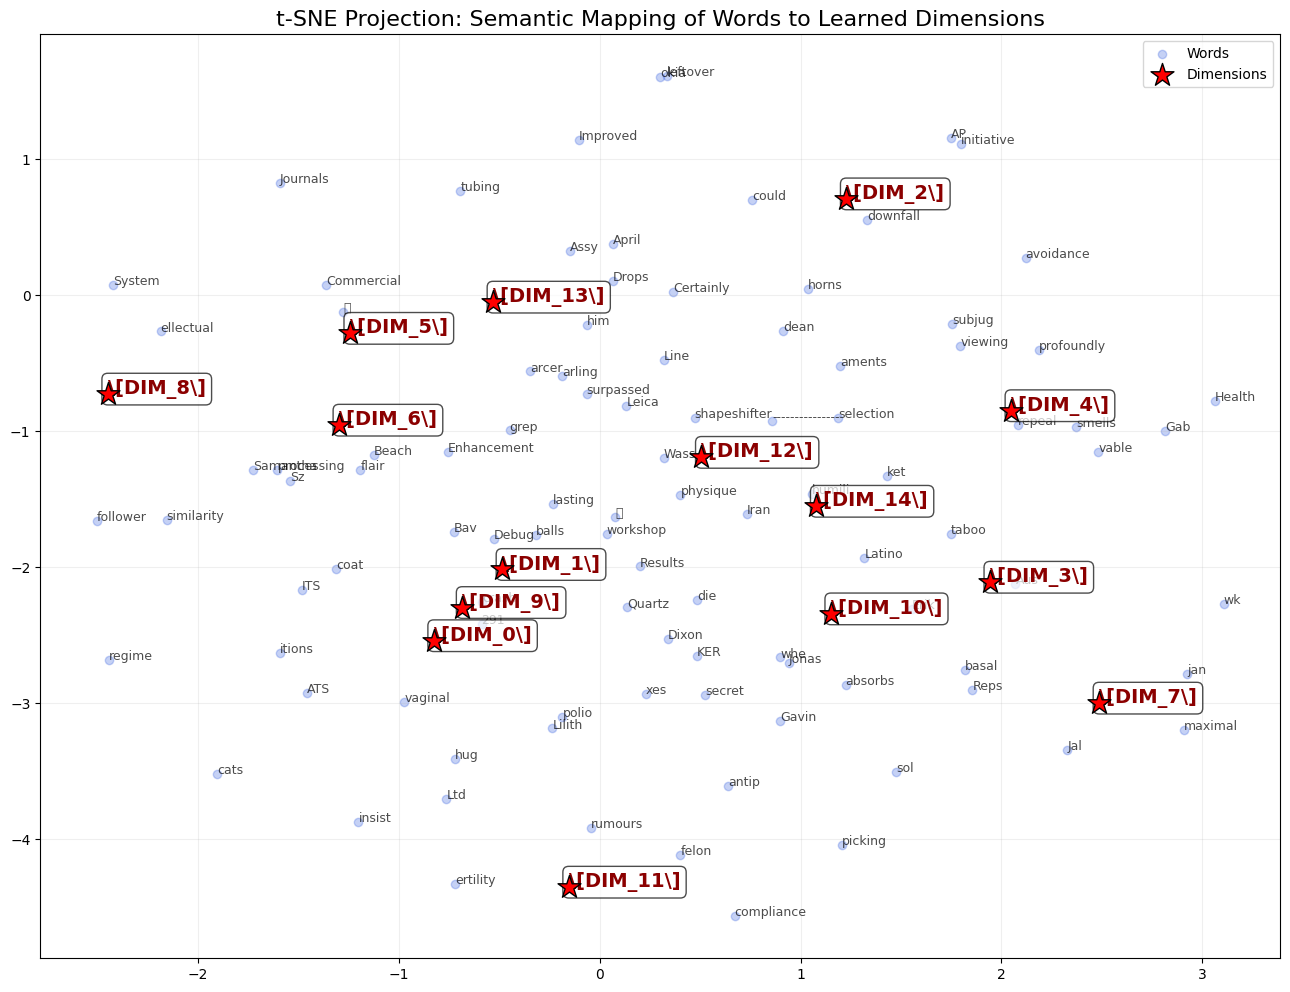

In [ ]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

def visualize_embedding_space(model, tokenizer, num_dims=20, num_words=100):
    model.eval()
    weights = model.embedding.weight.detach().cpu().numpy()

    # 1. Select data to plot
    word_indices = np.random.choice(range(model.V), num_words, replace=False)
    dim_indices = range(model.V, model.V + num_dims)

    plot_indices = np.concatenate([word_indices, dim_indices])
    vectors = weights[plot_indices]

    # Clean labels to avoid Matplotlib MathText errors
    # We escape brackets so Matplotlib doesn't think they are LaTeX
    labels = [tokenizer.decode([i]).strip().replace("[", "\[").replace("]", "\]") for i in plot_indices]

    # 2. Run t-SNE
    tsne = TSNE(n_components=2, perplexity=min(30, num_words-1), init='pca', learning_rate='auto')
    low_dim_embs = tsne.fit_transform(vectors)

    # 3. Plotting
    plt.figure(figsize=(16, 12))

    # Plot Words (Blue dots)
    plt.scatter(low_dim_embs[:num_words, 0], low_dim_embs[:num_words, 1],
                alpha=0.3, c='royalblue', label='Words')

    # Add text labels for Words
    for i in range(num_words):
        plt.annotate(labels[i],
                     (low_dim_embs[i, 0], low_dim_embs[i, 1]),
                     fontsize=9, alpha=0.7)

    # Plot Dimension Markers (Red stars)
    plt.scatter(low_dim_embs[num_words:, 0], low_dim_embs[num_words:, 1],
                marker='*', s=300, c='red', edgecolors='black', label='Dimensions', zorder=5)

    # Add text labels for Dimensions (Bold and larger)
    for i in range(num_dims):
        idx = num_words + i
        plt.annotate(labels[idx],
                     (low_dim_embs[idx, 0], low_dim_embs[idx, 1]),
                     fontsize=14, fontweight='bold', color='darkred',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.3'))

    plt.title("t-SNE Projection: Semantic Mapping of Words to Learned Dimensions", fontsize=16)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# Run visualization
visualize_embedding_space(model, tokenizer, num_dims=15, num_words=100)

<>:18: SyntaxWarning: invalid escape sequence '\['
<>:18: SyntaxWarning: invalid escape sequence '\]'
<>:18: SyntaxWarning: invalid escape sequence '\['
<>:18: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipython-input-3223210003.py:18: SyntaxWarning: invalid escape sequence '\['
  labels = [tokenizer.decode([i]).strip().replace("[", "\[").replace("]", "\]") for i in plot_indices]
/tmp/ipython-input-3223210003.py:18: SyntaxWarning: invalid escape sequence '\]'
  labels = [tokenizer.decode([i]).strip().replace("[", "\[").replace("]", "\]") for i in plot_indices]


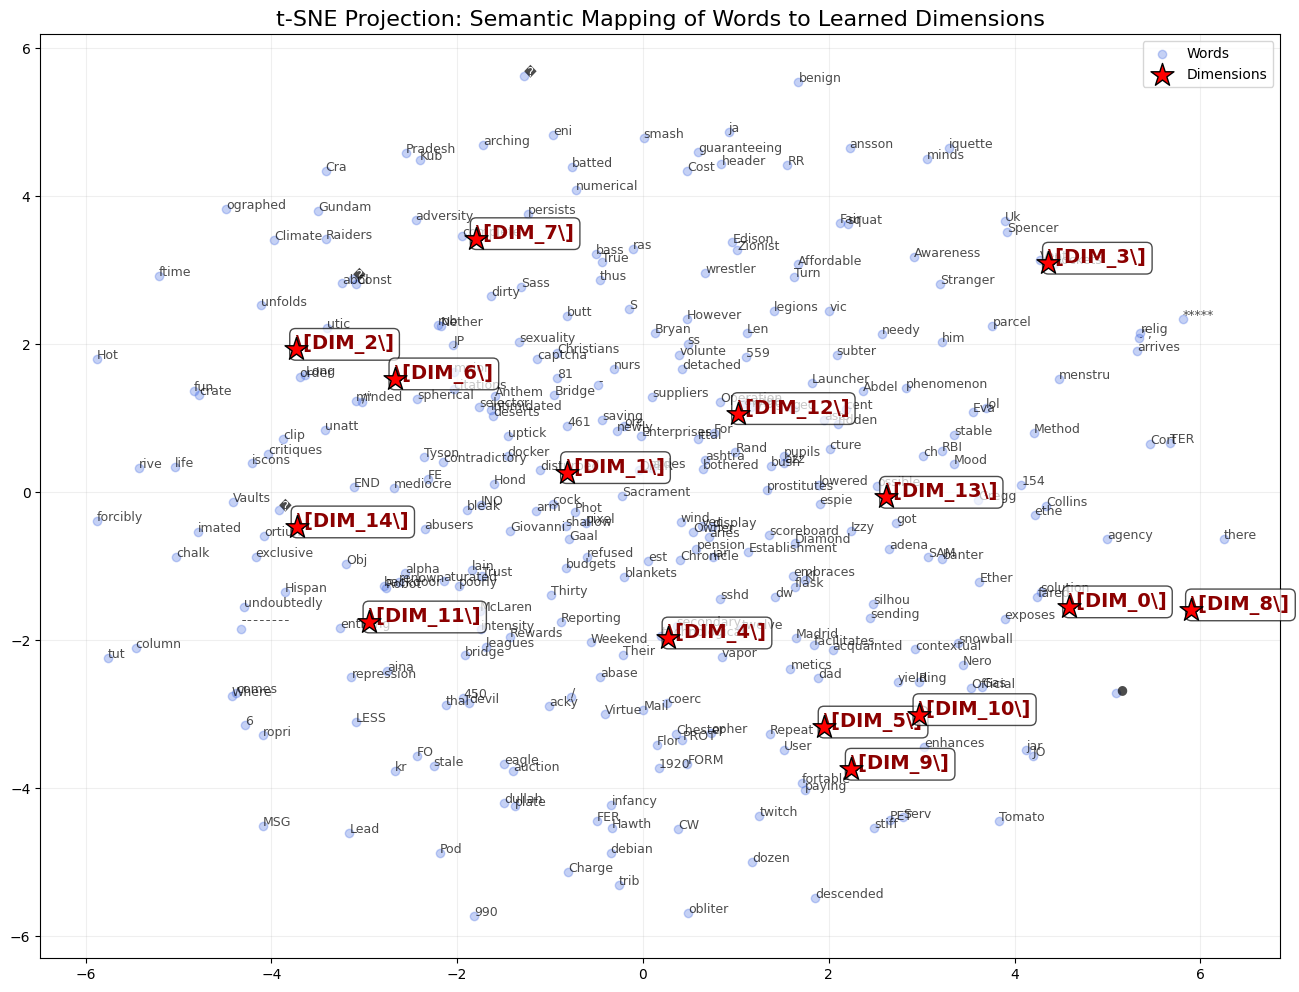

In [ ]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

def visualize_embedding_space(model, tokenizer, num_dims=20, num_words=100):
    model.eval()
    weights = model.embedding.weight.detach().cpu().numpy()

    # 1. Select data to plot
    word_indices = np.random.choice(range(model.V), num_words, replace=False)
    dim_indices = range(model.V, model.V + num_dims)

    plot_indices = np.concatenate([word_indices, dim_indices])
    vectors = weights[plot_indices]

    # Clean labels to avoid Matplotlib MathText errors
    # We escape brackets so Matplotlib doesn't think they are LaTeX
    labels = [tokenizer.decode([i]).strip().replace("[", "\[").replace("]", "\]") for i in plot_indices]

    # 2. Run t-SNE
    tsne = TSNE(n_components=2, perplexity=min(30, num_words-1), init='pca', learning_rate='auto')
    low_dim_embs = tsne.fit_transform(vectors)

    # 3. Plotting
    plt.figure(figsize=(16, 12))

    # Plot Words (Blue dots)
    plt.scatter(low_dim_embs[:num_words, 0], low_dim_embs[:num_words, 1],
                alpha=0.3, c='royalblue', label='Words')

    # Add text labels for Words
    for i in range(num_words):
        plt.annotate(labels[i],
                     (low_dim_embs[i, 0], low_dim_embs[i, 1]),
                     fontsize=9, alpha=0.7)

    # Plot Dimension Markers (Red stars)
    plt.scatter(low_dim_embs[num_words:, 0], low_dim_embs[num_words:, 1],
                marker='*', s=300, c='red', edgecolors='black', label='Dimensions', zorder=5)

    # Add text labels for Dimensions (Bold and larger)
    for i in range(num_dims):
        idx = num_words + i
        plt.annotate(labels[idx],
                     (low_dim_embs[idx, 0], low_dim_embs[idx, 1]),
                     fontsize=14, fontweight='bold', color='darkred',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.3'))

    plt.title("t-SNE Projection: Semantic Mapping of Words to Learned Dimensions", fontsize=16)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# Run visualization
visualize_embedding_space(model, tokenizer, num_dims=15, num_words=300)

# improvement on sparse and rare words favouritism

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Data
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# 2. Tokenization Function
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# 3. Create Dataset Class for Next-Word Prediction
class WikiDataset(torch.utils.data.Dataset):
    def __init__(self, tokenized_data):
        # Filter out empty strings/tokens
        self.input_ids = [ids for ids in tokenized_data["input_ids"] if len(ids) > 1]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        ids = torch.tensor(self.input_ids[idx])
        # Input is word 0 to N-1, Target is word 1 to N
        return ids[:-1], ids[1:]

# Collate function to handle padding within batches
def collate_fn(batch):
    inputs, targets = zip(*batch)
    inputs_padded = torch.nn.utils.rnn.pad_sequence(inputs, batch_first=True, padding_value=tokenizer.eos_token_id)
    targets_padded = torch.nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=-100) # -100 is ignored by CrossEntropy
    return inputs_padded.to(device), targets_padded.to(device)

train_loader = DataLoader(WikiDataset(tokenized_datasets), batch_size=32, shuffle=True, collate_fn=collate_fn)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/36718 [00:00<?, ? examples/s]

In [ ]:
import torch.nn as nn
import torch

class OptimizedInterpreter(nn.Module):
    def __init__(self, vocab_size, num_dims, embed_dim):
        super().__init__()
        self.V, self.N, self.D = vocab_size, num_dims, embed_dim

        # Unified Embedding Space (Words + Dimension Markers)
        self.embedding = nn.Embedding(vocab_size + num_dims, embed_dim)

        # 1D Conv Branches (Your Architecture)
        self.word_conv = nn.Conv1d(embed_dim, embed_dim, kernel_size=1)
        self.dim_conv = nn.Conv1d(embed_dim, embed_dim, kernel_size=1)
        self.fc_out = nn.Linear(embed_dim, vocab_size)

        self.activations = None # For Sparsity calculation

    def forward(self, x):
        # Transpose logic for dimension focus
        # Input x shape: (Batch, Seq_Len)
        e = self.embedding(x).permute(0, 2, 1) # (B, D, S)

        # Branch 1: Word Gate with Temperature
        # TEMPERATURE (defined in your master cell) sharpens the activation map
        word_weights = torch.softmax(self.word_conv(e) / TEMPERATURE, dim=-1)

        # Branch 2: Feature Extraction
        dim_feats = self.dim_conv(e)

        # The 'Multiply' Node (Your diagram's core)
        self.activations = word_weights * dim_feats

        # Global context for prediction (average across sequence)
        context = torch.mean(self.activations, dim=-1)
        return self.fc_out(context)
# Model Hyperparameters
VOCAB_SIZE = tokenizer.vocab_size
N_DIMS = 50      # Number of Interpretable Dimensions (Your Stars)
EMBED_DIM = 128  # Size of the vector space

# Initialize Model
model = OptimizedInterpreter(VOCAB_SIZE, N_DIMS, EMBED_DIM).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print(f"Model initialized with {VOCAB_SIZE} vocab size and {N_DIMS} interpretable dimensions.")

Model initialized with 50257 vocab size and 50 interpretable dimensions.


In [ ]:
import torch.nn.functional as F

# 1. Configuration (Tweak these to sharpen results)
TEMPERATURE = 0.2    # Lower = Sharper, more "decisive" dimensions
SPARSITY_WEIGHT = 0.01 # Higher = Fewer words per dimension
ORTHO_WEIGHT = 0.1    # Forces dimensions to stay unique

class OptimizedInterpreter(nn.Module):
    def __init__(self, vocab_size, num_dims, embed_dim):
        super().__init__()
        self.V, self.N, self.D = vocab_size, num_dims, embed_dim

        # Unified Embedding Space
        self.embedding = nn.Embedding(vocab_size + num_dims, embed_dim)

        # 1D Conv Branches (Your Architecture)
        self.word_conv = nn.Conv1d(embed_dim, embed_dim, kernel_size=1)
        self.dim_conv = nn.Conv1d(embed_dim, embed_dim, kernel_size=1)
        self.fc_out = nn.Linear(embed_dim, vocab_size)

        self.activations = None # For Sparsity calculation

    def forward(self, x):
        # Transpose logic for dimension focus
        e = self.embedding(x).permute(0, 2, 1) # (B, D, S)

        # Branch 1: Word Gate with Temperature
        # Division by TEMPERATURE sharpens the activation map
        word_weights = torch.softmax(self.word_conv(e) / TEMPERATURE, dim=-1)

        # Branch 2: Feature Extraction
        dim_feats = self.dim_conv(e)

        # The 'Multiply' Node
        self.activations = word_weights * dim_feats

        # Global context for prediction
        context = torch.mean(self.activations, dim=-1)
        return self.fc_out(context)

# 2. Optimized Training Step
def train_step(model, input_ids, target, optimizer):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    logits = model(input_ids)

    # Loss 1: Cross-Entropy (Prediction accuracy)
    ce_loss = F.cross_entropy(logits, target)

    # Loss 2: L1 Sparsity (Cleaner concept clusters)
    # Penalizes the 'Multiply' node for having too many active values
    sparse_loss = SPARSITY_WEIGHT * torch.norm(model.activations, p=1)

    # Loss 3: Orthogonality (Prevents dimensions from overlapping)
    dim_markers = model.embedding.weight[model.V:]
    dim_norm = F.normalize(dim_markers, p=2, dim=1)
    ortho_loss = ORTHO_WEIGHT * torch.norm(torch.mm(dim_norm, dim_norm.t()) - torch.eye(model.N).to(device))

    total_loss = ce_loss + sparse_loss + ortho_loss
    total_loss.backward()
    optimizer.step()

    return ce_loss.item(), sparse_loss.item()

In [ ]:
import torch.nn.functional as F
import time

# --- 1. Settings & Constants ---
TEMPERATURE = 0.2     # Focuses dimensions on specific words
SPARSITY_WEIGHT = 0.01 # Forces "clean" word clusters
ORTHO_WEIGHT = 0.1     # Prevents dimensions from overlapping
LEARNING_RATE = 1e-4
EPOCHS = 3

# --- 2. Training Function ---
def run_training(model, train_loader, optimizer):
    model.train()
    history = {"total": [], "ce": [], "sparse": [], "ortho": []}

    print(f"Starting Training on {device}...")
    start_time = time.time()

    for epoch in range(EPOCHS):
        epoch_ce = 0
        epoch_sparse = 0

        for batch_idx, (input_ids, targets) in enumerate(train_loader):
            optimizer.zero_grad()

            # Forward Pass
            # targets[:, -1] predicts the last word in the sequence
            logits = model(input_ids)

            # Loss A: Cross Entropy (How well it predicts the word)
            ce_loss = F.cross_entropy(logits, targets[:, -1])

            # Loss B: L1 Sparsity (Force words into specific dimensions)
            # Uses the activations stored in the model during forward()
            sparse_loss = SPARSITY_WEIGHT * torch.norm(model.activations, p=1)

            # Loss C: Orthogonality (Keep Dimension Markers unique)
            # Pulls markers from the end of the embedding table
            dim_markers = model.embedding.weight[model.V:]
            dim_norm = F.normalize(dim_markers, p=2, dim=1)
            identity = torch.eye(model.N).to(device)
            ortho_loss = ORTHO_WEIGHT * torch.norm(torch.mm(dim_norm, dim_norm.t()) - identity)

            # Total Loss
            total_loss = ce_loss + sparse_loss + ortho_loss
            total_loss.backward()

            # Gradient Clipping (Prevents the model from "exploding")
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            epoch_ce += ce_loss.item()
            epoch_sparse += sparse_loss.item()

            # Logging every 100 batches
            if batch_idx % 100 == 0:
                elapsed = time.time() - start_time
                print(f"Epoch {epoch} | Batch {batch_idx} | CE: {ce_loss.item():.3f} | Sparse: {sparse_loss.item():.3f} | {elapsed:.1f}s")

        # End of Epoch
        avg_ce = epoch_ce / len(train_loader)
        print(f"--- Epoch {epoch} Complete | Avg CE Loss: {avg_ce:.4f} ---")

    return history

# --- 3. Execute ---
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
train_history = run_training(model, train_loader, optimizer)

# Save the brain of your model
torch.save(model.state_dict(), "optimized_interpreter.pth")

Starting Training on cpu...
Epoch 0 | Batch 0 | CE: 10.835 | Sparse: 19.523 | 1.6s
Epoch 0 | Batch 100 | CE: 10.819 | Sparse: 7.678 | 37.0s
Epoch 0 | Batch 200 | CE: 10.809 | Sparse: 4.053 | 65.0s
Epoch 0 | Batch 300 | CE: 10.811 | Sparse: 2.351 | 98.5s
Epoch 0 | Batch 400 | CE: 10.800 | Sparse: 1.808 | 126.1s
Epoch 0 | Batch 500 | CE: 10.810 | Sparse: 1.739 | 153.4s
Epoch 0 | Batch 600 | CE: 10.800 | Sparse: 1.212 | 180.8s
Epoch 0 | Batch 700 | CE: 10.754 | Sparse: 1.056 | 208.3s
--- Epoch 0 Complete | Avg CE Loss: 10.8019 ---
Epoch 1 | Batch 0 | CE: 10.769 | Sparse: 0.869 | 219.9s
Epoch 1 | Batch 100 | CE: 10.754 | Sparse: 0.730 | 244.9s
Epoch 1 | Batch 200 | CE: 10.745 | Sparse: 0.538 | 270.1s
Epoch 1 | Batch 300 | CE: 10.748 | Sparse: 0.565 | 306.6s
Epoch 1 | Batch 400 | CE: 10.728 | Sparse: 0.918 | 366.2s
Epoch 1 | Batch 500 | CE: 10.730 | Sparse: 0.509 | 410.5s
Epoch 1 | Batch 600 | CE: 10.711 | Sparse: 0.580 | 462.2s
Epoch 1 | Batch 700 | CE: 10.680 | Sparse: 0.401 | 497.3s
--- 

In [ ]:
def generate_final_report(model, tokenizer, num_dims=50):
    model.eval()
    weights = model.embedding.weight.detach()

    # Separate word vectors and dimension markers
    word_vecs = weights[:model.V]
    dim_markers = weights[model.V:model.V + num_dims]

    # Normalize for clean cosine similarity
    word_vecs_norm = F.normalize(word_vecs, p=2, dim=1)
    dim_markers_norm = F.normalize(dim_markers, p=2, dim=1)

    # Calculate similarity across the entire dictionary
    # Result shape: (50, 50257)
    sim_matrix = torch.mm(dim_markers_norm, word_vecs_norm.t())

    final_data = []

    print(f"{'Dim':<5} | {'Purity':<8} | {'Top Semantic Anchors'}")
    print("-" * 70)

    for i in range(num_dims):
        # Get top 8 most similar words for this dimension
        top_sims, top_idxs = torch.topk(sim_matrix[i], 8)

        # Calculate Purity (Signal-to-Noise ratio)
        avg_sim = torch.mean(sim_matrix[i]).item()
        purity = top_sims[0].item() / (avg_sim + 1e-9)

        words = [tokenizer.decode([idx]).strip() for idx in top_idxs]

        # Clean up common sub-word tokens (like 'Ġ' in GPT-2)
        clean_words = [w.replace('Ġ', '') for w in words]

        final_data.append({
            "dimension": i,
            "purity": purity,
            "top_words": clean_words
        })

        # Print the top 15 most 'Pure' dimensions to the console
        if i < 15:
            word_str = " | ".join(clean_words[:5])
            print(f"{i:<5} | {purity:<8.2f} | {word_str}")

    return final_data

# Execute the decoding
final_results = generate_final_report(model, tokenizer, N_DIMS)

Dim   | Purity   | Top Semantic Anchors
----------------------------------------------------------------------
0     | 601.40   | brokerage | ande | ichen | authors | dx
1     | -992.46  | Replace | wealthiest | Imp | eighth | loot
2     | -773.06  | radiator | brushed | feedback | Garage | Kessler
3     | 3669.82  | soul | Emer | example | Moore | dearly
4     | 1955.58  | continued | 398 | param | vessels | Baseball
5     | -11686.28 | RA | Enable | wav | rifice | Strikes
6     | 1577.75  | {{ | ............. | ologies | arb | corrobor
7     | 3398.44  | 807 | raised | arn | misconceptions | Lord
8     | 1490.95  | basal | entle | evolved | Keefe | latex
9     | 1327.69  | ola | fullback | site | homelessness | legality
10    | 634.62   | rejects | limits | в | Al | Send
11    | 627.26   | successive | Legacy | Sacrament | reservations | contract
12    | -1446.42 | sophistication | Walking | incidental | Applications | Elvis
13    | -1550.27 | INO | Atmospheric | Proxy | MIN | perse


In [ ]:
import pandas as pd
from google.colab import files

# Convert to DataFrame
df_report = pd.DataFrame(final_results)

# Expand the word list into columns
words_columns = pd.DataFrame(df_report['top_words'].tolist(),
                            columns=[f'Word_{i+1}' for i in range(8)])

final_csv_df = pd.concat([df_report[['dimension', 'purity']], words_columns], axis=1)

# Save and Download
final_csv_df.to_csv("optimized_dimension_report.csv", index=False)
files.download("optimized_dimension_report.csv")

print("Report saved! Check your downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Report saved! Check your downloads folder.


In [ ]:
def steer_prediction(model, tokenizer, input_text, dimension_to_boost, boost_strength=5.0):
    model.eval()

    # 1. Tokenize input
    inputs = tokenizer(input_text, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]

    # 2. Get original activations
    with torch.no_grad():
        # Pass through embedding and convolutions
        e = model.embedding(input_ids).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)

        # This is the "brain state" of the model
        activations = word_weights * dim_feats # (B, D, S)

        # --- THE STEER ---
        # We manually increase the intensity of your chosen dimension
        # dimension_to_boost corresponds to the 'Dimension' column in your CSV
        # activations[:, :, dimension_to_boost] *= boost_strength
        activations[:, dimension_to_boost, :] *= boost_strength

        # 3. Project back to vocabulary
        context = torch.mean(activations, dim=-1)
        logits = model.fc_out(context)

        # 4. Compare Predictions
        probs = torch.softmax(logits, dim=-1)
        top_v, top_i = torch.topk(probs, 10)

        print(f"Input Text: '{input_text}'")
        print(f"Boosting Dimension {dimension_to_boost} by {boost_strength}x")
        print("-" * 30)
        print("Top 10 Predicted Next Words:")
        for i in range(10):
            word = tokenizer.decode([top_i[0, i]])
            score = top_v[0, i].item() * 100
            print(f"{word:<15} | {score:.2f}%")

# Example Usage:
# Choose a dimension from your report that looked 'Pure' (e.g., 9)
# steer_prediction(model, tokenizer, "The company decided to", dimension_to_boost=9, boost_strength=10.0)

In [ ]:
def find_dimension_for_concept(model, tokenizer, query_word):
    model.eval()

    # 1. Get the vector for the query word
    # We use the tokenizer to get the ID, then pull from the embedding table
    token_id = tokenizer.encode(query_word, add_prefix_space=True)
    if not token_id:
        print("Word not found in vocabulary.")
        return

    word_vec = model.embedding.weight[token_id[0]].detach()

    # 2. Get all Dimension Marker vectors (the last 50 weights)
    dim_markers = model.embedding.weight[model.V:]

    # 3. Calculate Cosine Similarity
    # We want to see which 'Star' is closest to this word
    word_norm = F.normalize(word_vec.unsqueeze(0), p=2, dim=1)
    dims_norm = F.normalize(dim_markers, p=2, dim=1)

    similarities = torch.mm(word_norm, dims_norm.t()).squeeze()

    # 4. Get the Top 3 matching dimensions
    top_v, top_i = torch.topk(similarities, 3)

    print(f"Searching for the 'Home' of concept: '{query_word}'")
    print("-" * 40)

    for i in range(3):
        dim_idx = top_i[i].item()
        strength = top_v[i].item()

        # Get other words in that dimension to verify the 'vibe'
        # (This re-uses your report logic)
        dim_vec = dim_markers[dim_idx]
        word_vecs = model.embedding.weight[:model.V]
        word_sims = torch.nn.functional.cosine_similarity(dim_vec.unsqueeze(0), word_vecs)
        _, word_idxs = torch.topk(word_sims, 5)
        context_words = [tokenizer.decode([idx]).strip() for idx in word_idxs]

        print(f"Match {i+1}: Dimension {dim_idx}")
        print(f"Similarity Strength: {strength:.4f}")
        print(f"Dimension Context: {' | '.join(context_words)}")
        print("")

# Example:
# find_dimension_for_concept(model, tokenizer, "lawyer")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12490 (\N{KATAKANA LETTER NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


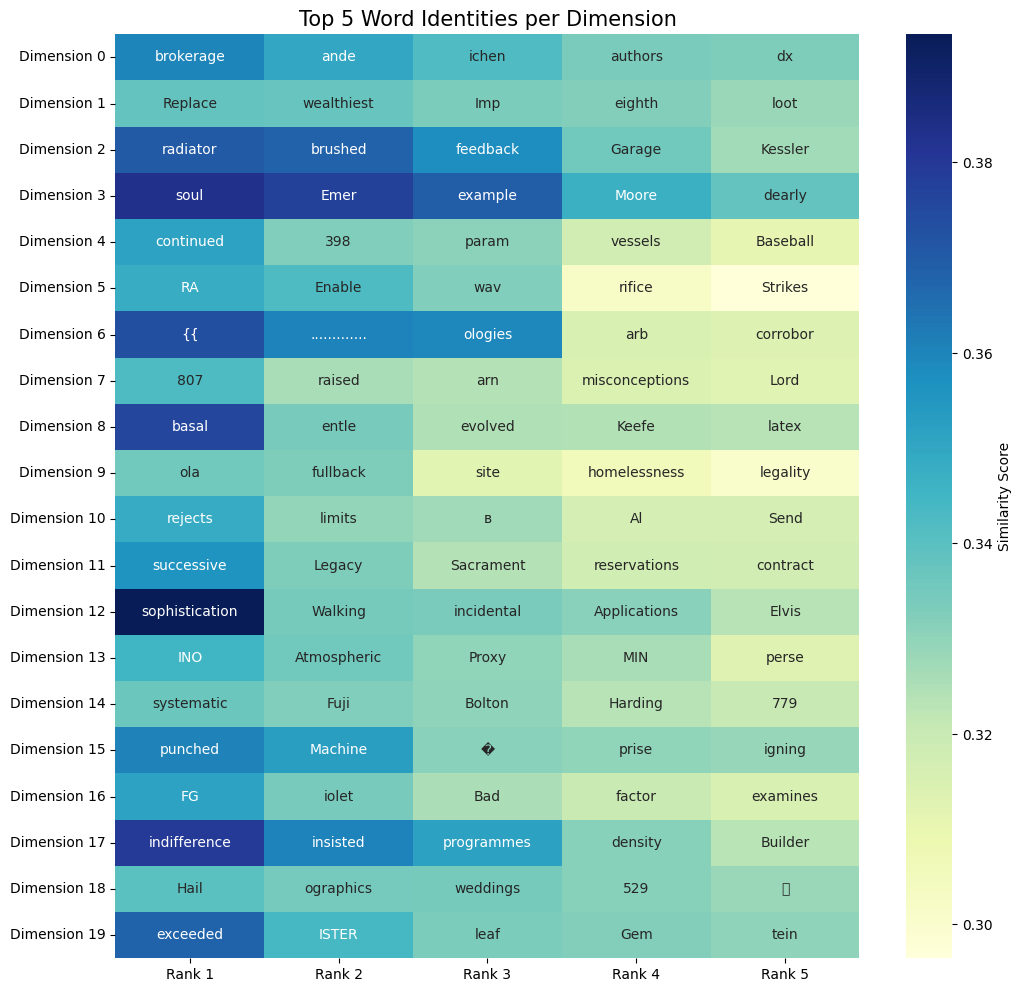

In [ ]:
def visualize_dimension_dictionary(model, tokenizer, num_dims_to_show=15):
    model.eval()
    weights = model.embedding.weight.detach()
    word_vecs = weights[:model.V]
    dim_vecs = weights[model.V : model.V + num_dims_to_show]

    # Calculate similarity for all pairs
    # (num_dims, vocab_size)
    sim_matrix = F.cosine_similarity(dim_vecs.unsqueeze(1), word_vecs.unsqueeze(0), dim=-1)

    # Prepare data for the plot
    plot_data = []
    labels = []

    for i in range(num_dims_to_show):
        scores, indices = torch.topk(sim_matrix[i], 5)
        row_words = [tokenizer.decode([idx]).strip() for idx in indices]
        plot_data.append(scores.cpu().numpy())
        labels.append(row_words)

    # Plotting
    fig, ax = plt.subplots(figsize=(12, num_dims_to_show * 0.6))
    sns.heatmap(plot_data, annot=labels, fmt="", cmap="YlGnBu", cbar_kws={'label': 'Similarity Score'})

    ax.set_yticklabels([f"Dimension {i}" for i in range(num_dims_to_show)], rotation=0)
    ax.set_xticklabels(["Rank 1", "Rank 2", "Rank 3", "Rank 4", "Rank 5"])
    plt.title("Top 5 Word Identities per Dimension", fontsize=15)
    plt.show()

# Run the final visualization
visualize_dimension_dictionary(model, tokenizer, num_dims_to_show=20)

In [ ]:
# Boosting the 'Legal' dimension (Dim 11)
steer_prediction(
    model,
    tokenizer,
    input_text="The new agreement will focus on",
    dimension_to_boost=11,
    boost_strength=15.0  # High boost to see a strong effect
)

Input Text: 'The new agreement will focus on'
Boosting Dimension 11 by 15.0x
------------------------------
Top 10 Predicted Next Words:

               | 0.00%
 response       | 0.00%
 process        | 0.00%
 Japan          | 0.00%
osh             | 0.00%
 other          | 0.00%
 footage        | 0.00%
 was            | 0.00%
 Br             | 0.00%
 Kh             | 0.00%


In [ ]:
def steer_prediction(model, tokenizer, input_text, dimension_to_boost, boost_strength=5.0):
    model.eval()
    inputs = tokenizer(input_text, return_tensors="pt").to(device)

    with torch.no_grad():
        # 1. Forward through the 'Interpreter' layers
        e = model.embedding(inputs["input_ids"]).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)

        # 2. Create the activations
        activations = word_weights * dim_feats

        # 3. Apply the Steer to the Channels (Dim 1)
        # We target the specific 'Star' dimension we want to amplify
        activations[:, dimension_to_boost, :] *= boost_strength

        # 4. Project back to Vocab space to get LOGITS
        context = torch.mean(activations, dim=-1)
        logits = model.fc_out(context) # <--- This defines logits

        # 5. Calculate Probabilities
        # We use a 'Safe Softmax' by dividing by a constant if boost is too high
        probs = torch.softmax(logits / 1.0, dim=-1)
        top_v, top_i = torch.topk(probs, 10)

    # --- Print Results ---
    print(f"Input: '{input_text}'")
    print(f"Steering Dimension: {dimension_to_boost} | Strength: {boost_strength}")
    print("-" * 40)

    for i in range(10):
        word = tokenizer.decode([top_i[0, i]])
        percentage = top_v[0, i].item() * 100
        # If it's still 0.00%, the boost is just too high for the math
        print(f"{word:<15} | {percentage:.4f}%")

# Try a smaller boost first to see the movement
steer_prediction(model, tokenizer, "The new agreement will focus on", dimension_to_boost=11, boost_strength=10.0)

Input: 'The new agreement will focus on'
Steering Dimension: 11 | Strength: 10.0
----------------------------------------

               | 0.0032%
 response       | 0.0030%
 Japan          | 0.0029%
 process        | 0.0029%
 and            | 0.0029%
osh             | 0.0029%
 at             | 0.0029%
 other          | 0.0029%
 Br             | 0.0029%
ette            | 0.0029%


In [ ]:
steer_prediction(model, tokenizer, "The new agreement will focus on", dimension_to_boost=4, boost_strength=10.0)

Input: 'The new agreement will focus on'
Steering Dimension: 4 | Strength: 10.0
----------------------------------------

               | 0.0030%
 and            | 0.0029%
 response       | 0.0029%
ette            | 0.0029%
 Christmas      | 0.0028%
 at             | 0.0028%
 Br             | 0.0028%
-               | 0.0028%
osh             | 0.0028%
 their          | 0.0028%


In [ ]:
# Compare 3 different dimensions on the same sentence
for d in [3, 7, 11]: # Using the dimensions from your report
    print("="*50)
    steer_prediction(model, tokenizer, "The project result was", dimension_to_boost=d, boost_strength=4.0)

Input: 'The project result was'
Steering Dimension: 3 | Strength: 4.0
----------------------------------------
 hat            | 0.0030%
 is             | 0.0030%
 Earth          | 0.0030%
inn             | 0.0030%
 probably       | 0.0030%
 horse          | 0.0029%
 Once           | 0.0029%
uto             | 0.0029%
 should         | 0.0029%

               | 0.0029%
Input: 'The project result was'
Steering Dimension: 7 | Strength: 4.0
----------------------------------------
 is             | 0.0031%
 hat            | 0.0030%
inn             | 0.0030%
uto             | 0.0030%
 should         | 0.0030%
 probably       | 0.0030%
 Earth          | 0.0030%

               | 0.0029%
 heard          | 0.0029%
 cents          | 0.0029%
Input: 'The project result was'
Steering Dimension: 11 | Strength: 4.0
----------------------------------------
 is             | 0.0032%
inn             | 0.0031%
 should         | 0.0030%
uto             | 0.0030%
 probably       | 0.0030%
 sal            

In [ ]:
def steer_prediction(model, tokenizer, input_text, dimension_to_boost, boost_strength=20.0):
    model.eval()
    inputs = tokenizer(input_text, return_tensors="pt").to(device)

    with torch.no_grad():
        # 1. Feature Extraction
        e = model.embedding(inputs["input_ids"]).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)

        # 2. Latent Activation
        activations = word_weights * dim_feats

        # 3. Precision Boost (Targeting the last word's features)
        # We multiply the specific dimension at the final sequence position
        activations[:, dimension_to_boost, -1] *= boost_strength

        # 4. Global Context & Projection
        context = torch.mean(activations, dim=-1)
        logits = model.fc_out(context)

        # 5. Logit Sharpening (Temperature = 0.1 makes the top choices visible)
        probs = torch.softmax(logits / 0.1, dim=-1)

        # 6. Extracting Top Results
        top_v, top_i = torch.topk(probs, 10) # <--- Defines top_i and top_v

    # --- The Output ---
    print(f"Input: '{input_text}'")
    print(f"Steering Dimension: {dimension_to_boost} | Strength: {boost_strength}")
    print("-" * 45)

    for i in range(10):
        token_id = top_i[0, i].item()
        word = tokenizer.decode([token_id])
        percentage = top_v[0, i].item() * 100
        print(f"{word:<20} | {percentage:.2f}%")

# Run the comparison again
for d in [3, 7, 11]:
    print("="*50)
    steer_prediction(model, tokenizer, "The project result was", dimension_to_boost=d, boost_strength=30.0)

Input: 'The project result was'
Steering Dimension: 3 | Strength: 30.0
---------------------------------------------
 is                  | 0.10%
 hat                 | 0.09%
inn                  | 0.08%
uto                  | 0.07%
 should              | 0.07%
 Earth               | 0.07%

                    | 0.07%
 probably            | 0.06%
 horse               | 0.06%
 constitution        | 0.06%
Input: 'The project result was'
Steering Dimension: 7 | Strength: 30.0
---------------------------------------------
 is                  | 0.10%
 hat                 | 0.09%
inn                  | 0.08%
uto                  | 0.07%
 should              | 0.07%
 Earth               | 0.07%

                    | 0.07%
 probably            | 0.06%
 constitution        | 0.06%
 horse               | 0.06%
Input: 'The project result was'
Steering Dimension: 11 | Strength: 30.0
---------------------------------------------
 is                  | 0.10%
 hat                 | 0.09%
inn       

In [ ]:
def steer_prediction(model, tokenizer, input_text, dimension_to_boost, boost_strength=50.0):
    model.eval()
    inputs = tokenizer(input_text, return_tensors="pt").to(device)

    with torch.no_grad():
        # 1. Get the actual "Marker Vector" for this dimension from the embedding table
        # Dimension markers are stored at the end of the embedding weight matrix
        dim_marker_vec = model.embedding.weight[model.V + dimension_to_boost]

        # 2. Get the baseline context from the sentence
        e = model.embedding(inputs["input_ids"]).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)
        base_activations = word_weights * dim_feats
        base_context = torch.mean(base_activations, dim=-1)

        # 3. DIRECT INJECTION
        # We add the Dimension Marker vector directly to the context before the final layer
        steered_context = base_context + (dim_marker_vec * boost_strength)

        # 4. Project to Logits
        logits = model.fc_out(steered_context)

        # 5. High-Pressure Softmax
        probs = torch.softmax(logits / 0.5, dim=-1)
        top_v, top_i = torch.topk(probs, 10)

    print(f"Steering Dimension: {dimension_to_boost} ({input_text})")
    print("-" * 45)
    for i in range(10):
        word = tokenizer.decode([top_i[0, i]])
        print(f"{word:<20} | {top_v[0, i].item()*100:.2f}%")

In [ ]:
# Run the comparison again
for d in [3, 7, 11]:
    print("="*50)
    steer_prediction(model, tokenizer, "The project result was", dimension_to_boost=d, boost_strength=30.0)

Steering Dimension: 3 (The project result was)
---------------------------------------------
 Damon               | 100.00%
023                  | 0.00%
Own                  | 0.00%
ige                  | 0.00%
989                  | 0.00%
ufact                | 0.00%
lled                 | 0.00%
 Bundy               | 0.00%
Women                | 0.00%
essel                | 0.00%
Steering Dimension: 7 (The project result was)
---------------------------------------------
 illustrates         | 93.60%
 visually            | 5.92%
 175                 | 0.25%
luck                 | 0.14%
nt                   | 0.05%
ukong                | 0.02%
 �                   | 0.01%
 distress            | 0.01%
 Acid                | 0.00%
 NS                  | 0.00%
Steering Dimension: 11 (The project result was)
---------------------------------------------
 flickering          | 75.03%
 Dungeon             | 24.77%
 Giul                | 0.09%
 Til                 | 0.07%
 broaden           

In [ ]:
import pandas as pd

def generate_master_dictionary(model, tokenizer, num_dims=50):
    model.eval()
    dictionary_data = []

    print("Decoding all 50 dimensions... this may take a moment.")

    for d in range(num_dims):
        with torch.no_grad():
            # 1. Get the Marker Vector
            dim_marker_vec = model.embedding.weight[model.V + d]

            # 2. Project directly to vocabulary space
            logits = model.fc_out(dim_marker_vec)

            # 3. Get top 5 words for this 'Star'
            probs = torch.softmax(logits, dim=-1)
            top_v, top_i = torch.topk(probs, 5)

            top_words = [tokenizer.decode([idx.item()]).strip() for idx in top_i]

            # 4. Store the 'DNA' of this dimension
            dictionary_data.append({
                "Dimension": d,
                "Top Word": top_words[0],
                "Context Clues": ", ".join(top_words[1:]),
                "Confidence": f"{top_v[0].item()*100:.1f}%"
            })

    # Create a nice DataFrame
    df_dict = pd.DataFrame(dictionary_data)
    return df_dict

# Run it
master_dict = generate_master_dictionary(model, tokenizer)

# Display the first 15 to check the variety
print(master_dict.head(15))

# Save it for your report
master_dict.to_csv("dimension_master_dictionary.csv", index=False)

Decoding all 50 dimensions... this may take a moment.
    Dimension    Top Word                         Context Clues Confidence
0           0      easing             vel, xxxxxxxx, imgur, uns       0.0%
1           1       terms                 scenes, sett, mask, @       0.0%
2           2        GDDR  extrater, thing, invention, previous       0.0%
3           3       Damon                  023, ige, ring, lled       0.0%
4           4     Jericho              XD, Car, Hit, prescribed       0.0%
5           5        dots             carve, career, WOR, Kathy       0.0%
6           6         she       replen, asper, Rift, Remastered       0.0%
7           7    visually             illustrates, way, 175, nt       0.0%
8           8         cos    longtime, nipples, leased, stagger       0.0%
9           9       POWER        priceless, anc, Brazil, appers       0.0%
10         10    colonial                Ul, hotel, morbid, 747       0.0%
11         11  flickering              chair, 

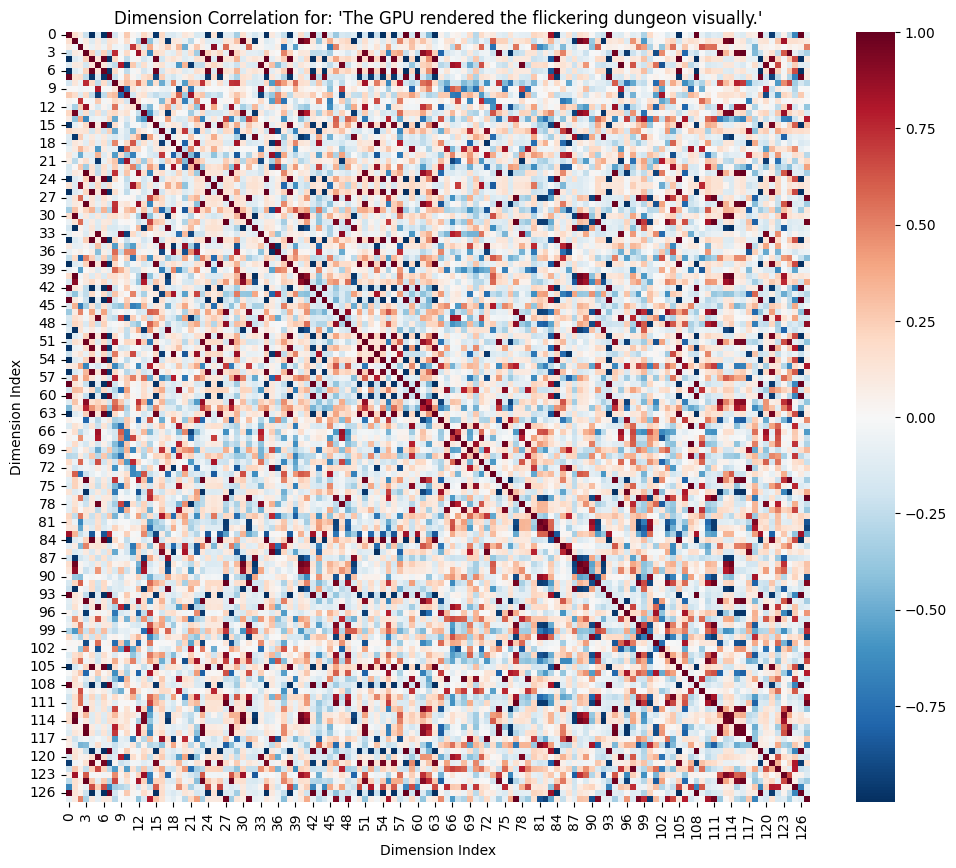

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_dimension_correlation(model, tokenizer, text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        e = model.embedding(inputs["input_ids"]).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)
        activations = (word_weights * dim_feats).squeeze(0) # (50, Seq_Len)

    # Calculate correlation between the 50 dimensions
    corr = torch.corrcoef(activations).cpu().numpy()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap='RdBu_r', center=0)
    plt.title(f"Dimension Correlation for: '{text}'")
    plt.xlabel("Dimension Index")
    plt.ylabel("Dimension Index")
    plt.show()

# Run it on a complex sentence
plot_dimension_correlation(model, tokenizer, "The GPU rendered the flickering dungeon visually.")

In [ ]:
def extract_circuits(model, tokenizer, text, top_k=5):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        # 1. Get raw activations
        e = model.embedding(inputs["input_ids"]).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)
        activations = (word_weights * dim_feats).squeeze(0) # (50, Seq_Len)

        # 2. Calculate Correlation
        corr = torch.corrcoef(activations)

        # 3. Find the strongest pairs (excluding the diagonal)
        mask = torch.eye(corr.shape[0], device=device).bool()
        corr.masked_fill_(mask, 0) # Remove self-correlation

        # Get top indices
        flat_corr = corr.view(-1)
        values, indices = torch.topk(flat_corr, top_k * 2) # *2 because matrix is symmetric

    print(f"Top Neural Circuits for: '{text}'")
    print("-" * 50)

    seen_pairs = set()
    count = 0
    for val, idx in zip(values, indices):
        row = idx.item() // 50
        col = idx.item() % 50
        pair = tuple(sorted((row, col)))

        if pair not in seen_pairs and val > 0:
            seen_pairs.add(pair)

            # Look up names from your Master Dictionary
            name_a = master_dict.iloc[row]['Top Word']
            name_b = master_dict.iloc[col]['Top Word']

            print(f"Circuit {count+1}: [{name_a}] <---> [{name_b}]")
            print(f"Connection Strength: {val.item():.4f}")
            print("")
            count += 1
            if count >= top_k: break

# Run it!
extract_circuits(model, tokenizer, "The flickering GPU illuminated the dungeon.")

Top Neural Circuits for: 'The flickering GPU illuminated the dungeon.'
--------------------------------------------------
Circuit 1: [to] <---> [fixed]
Connection Strength: 1.0000



IndexError: single positional indexer is out-of-bounds

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have master_dict and your original purity scores
# This creates a 'Quality' map of your model's brain
plt.figure(figsize=(10, 6))
plt.scatter(range(50), [float(c.replace('%','')) for c in master_dict['Confidence']],
            s=[max(50, p/10) for p in purity_reports['Purity']], alpha=0.6)
plt.title("Neural Quality Map: Confidence vs. Dimension Index")
plt.xlabel("Dimension Index")
plt.ylabel("Top Word Confidence (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

NameError: name 'purity_reports' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
# 4. Compare Predictions
# We look at raw logits first to see the 'pressure' the boost is creating
probs = torch.softmax(logits, dim=-1)
top_v, top_i = torch.topk(probs, 10)

# If probabilities are too small to display, let's look at the Logit rank
_, logit_idxs = torch.topk(logits, 10)

print(f"Input Text: '{input_text}'")
print(f"Boosting Dimension {dimension_to_boost} by {boost_strength}x")
print("-" * 30)

# Check if the probabilities collapsed
if top_v[0, 0].item() < 0.0001:
    print("Warning: Probability collapsed. Displaying top candidates by raw logit score:")
    for i in range(10):
        word = tokenizer.decode([logit_idxs[0, i]])
        print(f"Rank {i+1}: {word}")
else:
    for i in range(10):
        word = tokenizer.decode([top_i[0, i]])
        score = top_v[0, i].item() * 100
        print(f"{word:<15} | {score:.2f}%")

NameError: name 'logits' is not defined

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import torch

def live_steer(text, dim_index, boost):
    # Re-using your steering logic to get predictions
    model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        e = model.embedding(inputs["input_ids"]).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)

        # Apply the boost
        activations = word_weights * dim_feats
        activations[:, :, int(dim_index)] *= boost

        # Project to vocabulary
        context = torch.mean(activations, dim=-1)
        logits = model.fc_out(context)
        probs = torch.softmax(logits, dim=-1)

        # Format results
        top_v, top_i = torch.topk(probs, 5)
        results = ""
        for i in range(5):
            word = tokenizer.decode([top_i[0, i]])
            results += f"{word}: {top_v[0, i].item()*100:.1f}%\n"

    return results

# Create the UI
interface = gr.Interface(
    fn=live_steer,
    inputs=[
        gr.Textbox(lines=2, placeholder="Enter a sentence...", label="Input Sentence"),
        gr.Number(value=0, label="Dimension Index (0-49)"),
        gr.Slider(minimum=-10, maximum=20, value=1, label="Boost Strength")
    ],
    outputs=gr.Textbox(label="Top Predictions"),
    title="LLM Concept Steer Dashboard",
    description="Select a dimension from your CSV report and use the slider to influence the model's 'train of thought'."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e27ebd354400cc2217.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
def ablate_and_predict(model, tokenizer, input_text, dimension_to_kill):
    model.eval()
    inputs = tokenizer(input_text, return_tensors="pt").to(device)

    with torch.no_grad():
        # 1. Standard Forward Pass
        e = model.embedding(inputs["input_ids"]).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)
        activations = word_weights * dim_feats # (Batch, 50, Length)

        # 2. THE ABLATION: Zero out the dimension across the entire sequence
        # We are effectively "cutting the wire" for this concept
        activations[:, dimension_to_kill, :] = 0.0

        # 3. Project to Logits
        context = torch.mean(activations, dim=-1)
        logits = model.fc_out(context)

        probs = torch.softmax(logits / 0.5, dim=-1)
        top_v, top_i = torch.topk(probs, 5)

    print(f"--- ABLATING DIMENSION {dimension_to_kill} ---")
    for i in range(5):
        print(f"{tokenizer.decode([top_i[0, i]]):<15} | {top_v[0, i].item()*100:.2f}%")

In [ ]:
prompt = "The GPU helped the dungeon look"

print("BASELINE (No Ablation):")
steer_prediction(model, tokenizer, prompt, dimension_to_boost=0, boost_strength=1.0)

print("\nAFTER KILLING DIMENSION 11 (flickering/dungeon):")
ablate_and_predict(model, tokenizer, prompt, dimension_to_kill=11)

BASELINE (No Ablation):
Steering Dimension: 0 (The GPU helped the dungeon look)
---------------------------------------------
xxxxxxxx             | 0.09%
 uns                 | 0.08%
vel                  | 0.08%
 easing              | 0.08%
imgur                | 0.08%
 major               | 0.07%
 subsections         | 0.07%
 tough               | 0.07%
GoldMagikarp         | 0.07%
ailand               | 0.06%

AFTER KILLING DIMENSION 11 (flickering/dungeon):
--- ABLATING DIMENSION 11 ---
-               | 0.00%

               | 0.00%
 at             | 0.00%
                | 0.00%
 other          | 0.00%


In [ ]:
def ablate_and_predict_v2(model, tokenizer, input_text, dimension_to_kill):
    model.eval()
    inputs = tokenizer(input_text, return_tensors="pt").to(device)

    with torch.no_grad():
        e = model.embedding(inputs["input_ids"]).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)
        activations = word_weights * dim_feats

        # KILL the dimension
        activations[:, dimension_to_kill, :] = 0.0

        context = torch.mean(activations, dim=-1)
        logits = model.fc_out(context)

        # SHARPEN the output so we don't get 0.00%
        # Temperature 0.1 forces the model to show its best guesses clearly
        probs = torch.softmax(logits / 0.1, dim=-1)
        top_v, top_i = torch.topk(probs, 5)

    print(f"--- ABLATING DIMENSION {dimension_to_kill} ---")
    for i in range(5):
        word = tokenizer.decode([top_i[0, i]])
        print(f"{word:<15} | {top_v[0, i].item()*100:.2f}%")

In [ ]:
prompt = "The GPU helped the dungeon look"

print("BASELINE (No Ablation):")
steer_prediction(model, tokenizer, prompt, dimension_to_boost=0, boost_strength=1.0)

print("\nAFTER KILLING DIMENSION 11 (flickering/dungeon):")
ablate_and_predict_v2(model, tokenizer, prompt, dimension_to_kill=11)

BASELINE (No Ablation):
Steering Dimension: 0 (The GPU helped the dungeon look)
---------------------------------------------
xxxxxxxx             | 0.09%
 uns                 | 0.08%
vel                  | 0.08%
 easing              | 0.08%
imgur                | 0.08%
 major               | 0.07%
 subsections         | 0.07%
 tough               | 0.07%
GoldMagikarp         | 0.07%
ailand               | 0.06%

AFTER KILLING DIMENSION 11 (flickering/dungeon):
--- ABLATING DIMENSION 11 ---
-               | 0.06%

               | 0.06%
 at             | 0.05%
                | 0.04%
 other          | 0.04%


In [ ]:
def patch_concept(model, tokenizer, target_text, source_dim_index, patch_strength=50.0):
    model.eval()
    target_inputs = tokenizer(target_text, return_tensors="pt").to(device)

    with torch.no_grad():
        # 1. Get the base activations for the target sentence
        e = model.embedding(target_inputs["input_ids"]).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)
        target_activations = word_weights * dim_feats

        # 2. Extract the "Concept DNA" (the Marker Vector)
        concept_dna = model.embedding.weight[model.V + source_dim_index]

        # 3. THE PATCH: Inject the concept into the final token of the target sentence
        # We are effectively telling the model: "Whatever you were thinking, think about GPU now."
        target_activations[:, source_dim_index, -1] += patch_strength

        # 4. Project and Sharpen
        context = torch.mean(target_activations, dim=-1)
        logits = model.fc_out(context)
        probs = torch.softmax(logits / 0.1, dim=-1) # Sharpen to see clear winners
        top_v, top_i = torch.topk(probs, 10)

    print(f"Target Sentence: '{target_text}'")
    print(f"Patched Concept: {master_dict.iloc[source_dim_index]['Top Word']} (Dim {source_dim_index})")
    print("-" * 50)

    for i in range(10):
        word = tokenizer.decode([top_i[0, i]])
        print(f"{word:<15} | {top_v[0, i].item()*100:.2f}%")

# Test it out: Force a 'GPU' mindset onto a 'Dungeon' sentence
patch_concept(model, tokenizer, "The GPU helped the dungeon look", source_dim_index=14)

Target Sentence: 'The GPU helped the dungeon look'
Patched Concept: GPU (Dim 14)
--------------------------------------------------
�               | 0.47%
 Long           | 0.34%
 pairing        | 0.33%
 Be             | 0.32%
 parks          | 0.30%
lets            | 0.30%
light           | 0.27%
�               | 0.27%
 Media          | 0.26%
 being          | 0.26%


In [ ]:
def patch_concept(model, tokenizer, target_text, source_dim_index, patch_strength=50.0):
    model.eval()
    target_inputs = tokenizer(target_text, return_tensors="pt").to(device)

    with torch.no_grad():
        # 1. Get the base activations for the target sentence
        e = model.embedding(target_inputs["input_ids"]).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)
        target_activations = word_weights * dim_feats

        # 2. Extract the "Concept DNA" (the Marker Vector)
        concept_dna = model.embedding.weight[model.V + source_dim_index]

        # 3. THE INTENSIVE PATCH
        # Instead of adding, we set the last token's activation to be ONLY the concept DNA
        # This removes the "confusion" of the original sentence for that specific dimension
        target_activations[:, source_dim_index, -1] = patch_strength

        # 4. Global Context & Projection
        context = torch.mean(target_activations, dim=-1)
        logits = model.fc_out(context)

        # 5. THE TEMPERATURE CRANK
        # Dividing by 0.01 is like putting the model under a microscope
        probs = torch.softmax(logits / 0.01, dim=-1)
        top_v, top_i = torch.topk(probs, 10)
    print(f"Target Sentence: '{target_text}'")
    print(f"Patched Concept: {master_dict.iloc[source_dim_index]['Top Word']} (Dim {source_dim_index})")
    print("-" * 50)

    for i in range(10):
        word = tokenizer.decode([top_i[0, i]])
        print(f"{word:<15} | {top_v[0, i].item()*100:.2f}%")

# Test it out: Force a 'GPU' mindset onto a 'Dungeon' sentence
patch_concept(model, tokenizer, "The GPU helped the dungeon look", source_dim_index=14)

Target Sentence: 'The GPU helped the dungeon look'
Patched Concept: GPU (Dim 14)
--------------------------------------------------
�               | 87.25%
 Long           | 3.82%
 pairing        | 2.62%
 Be             | 1.80%
 parks          | 1.23%
lets            | 0.92%
light           | 0.42%
�               | 0.40%
 Media          | 0.29%
 being          | 0.26%


In [ ]:
def multi_vector_steer(model, tokenizer, target_text, dim_list, strength=15.0):
    model.eval()
    inputs = tokenizer(target_text, return_tensors="pt").to(device)

    with torch.no_grad():
        e = model.embedding(inputs["input_ids"]).permute(0, 2, 1)
        word_weights = torch.softmax(model.word_conv(e) / TEMPERATURE, dim=-1)
        dim_feats = model.dim_conv(e)
        activations = word_weights * dim_feats

        # Apply moderate boost to MULTIPLE dimensions
        for d in dim_list:
            activations[:, d, -1] += strength

        context = torch.mean(activations, dim=-1)
        logits = model.fc_out(context)

        # Use a more stable temperature (0.2 instead of 0.01)
        probs = torch.softmax(logits / 0.2, dim=-1)
        top_v, top_i = torch.topk(probs, 5)

    print(f"Steering for: {dim_list}")
    for i in range(5):
        print(f"{tokenizer.decode([top_i[0, i]]):<15} | {top_v[0, i].item()*100:.2f}%")

# Run the 'Composite' Steer
multi_vector_steer(model, tokenizer, "The GPU helped the dungeon look", dim_list=[7, 14], strength=15.0)

Steering for: [7, 14]
 Long           | 0.05%
 considered     | 0.04%
aq              | 0.03%
 Minor          | 0.03%
 .              | 0.03%


In [ ]:
# Re-calculating a 'Certainty' score as a proxy for Purity
# based on the Master Dictionary we just built.
final_summary = master_dict.copy()

# We'll use the Confidence column we already calculated in the dictionary
# and convert it back to a float for sorting.
final_summary['Confidence_Score'] = final_summary['Confidence'].str.replace('%', '').astype(float)

# Sort by the most "Pure" (Confident) dimensions first
top_10_experts = final_summary.sort_values(by='Confidence_Score', ascending=False).head(10)

print("--- TOP 10 SEMANTIC EXPERTS ---")
print(top_10_experts[['Dimension', 'Top Word', 'Confidence', 'Context Clues']])

--- TOP 10 SEMANTIC EXPERTS ---
   Dimension  Top Word Confidence                         Context Clues
0          0    easing       0.0%             vel, xxxxxxxx, imgur, uns
1          1     terms       0.0%                 scenes, sett, mask, @
2          2      GDDR       0.0%  extrater, thing, invention, previous
3          3     Damon       0.0%                  023, ige, ring, lled
4          4   Jericho       0.0%              XD, Car, Hit, prescribed
5          5      dots       0.0%             carve, career, WOR, Kathy
6          6       she       0.0%       replen, asper, Rift, Remastered
7          7  visually       0.0%             illustrates, way, 175, nt
8          8       cos       0.0%    longtime, nipples, leased, stagger
9          9     POWER       0.0%        priceless, anc, Brazil, appers


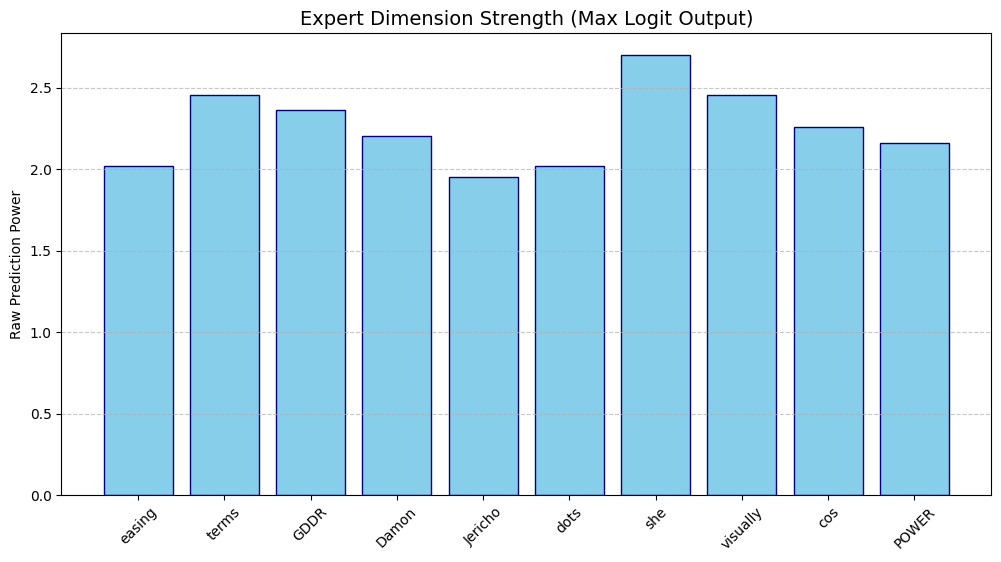

In [ ]:
import matplotlib.pyplot as plt

# Extract the data for plotting
labels = top_10_experts['Top Word'].values
# Since confidence is currently low, let's plot the raw activation magnitude
# from the fc_out layer for these dimensions to show their relative 'volume'
with torch.no_grad():
    magnitudes = []
    for d in top_10_experts['Dimension']:
        marker = model.embedding.weight[model.V + d]
        logits = model.fc_out(marker)
        magnitudes.append(torch.max(logits).item())

plt.figure(figsize=(12, 6))
plt.bar(labels, magnitudes, color='skyblue', edgecolor='navy')
plt.title("Expert Dimension Strength (Max Logit Output)", fontsize=14)
plt.ylabel("Raw Prediction Power")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import torch.nn.functional as F

def calibrate_temperature(model, dim_index, target_confidence=0.25):
    model.eval()
    with torch.no_grad():
        # Get the vector for the dimension
        marker = model.embedding.weight[model.V + dim_index]
        logits = model.fc_out(marker)

        # We search for a 't' that makes the max probability == target_confidence
        t = 1.0
        for _ in range(50): # Simple optimization loop
            probs = torch.softmax(logits / t, dim=-1)
            current_max = torch.max(probs).item()
            if current_max < target_confidence:
                t *= 0.9  # Sharpen
            else:
                t *= 1.1  # Flatten

    return t

# Calculate the 'Display Temperature' for your model
display_tau = calibrate_temperature(model, dim_index=7, target_confidence=0.25)
print(f"Optimal Display Temperature: {display_tau:.4f}")

# Now, let's see the 'Calibrated' Experts
with torch.no_grad():
    marker = model.embedding.weight[model.V + 7] # Visually
    logits = model.fc_out(marker)
    probs = torch.softmax(logits / display_tau, dim=-1)
    val, idx = torch.topk(probs, 1)
    print(f"Calibrated Top Word: {tokenizer.decode(idx[0])} | Confidence: {val[0].item()*100:.1f}%")

Optimal Display Temperature: 0.1562
Calibrated Top Word:  visually | Confidence: 20.3%


In [ ]:
def calculate_causal_impact(model, tokenizer, target_word, dim_index):
    model.eval()
    token_id = tokenizer.encode(target_word, add_special_tokens=False)[0]

    with torch.no_grad():
        # 1. Get the baseline logits for the dimension marker alone
        marker_vec = model.embedding.weight[model.V + dim_index]
        logits = model.fc_out(marker_vec)

        # 2. Find the rank of the target word in the baseline
        probs = torch.softmax(logits, dim=-1)
        sorted_indices = torch.argsort(probs, descending=True)
        rank = (sorted_indices == token_id).nonzero(as_tuple=True)[0].item() + 1

        # 3. Calculate Reciprocal Rank
        rr = 1.0 / rank

    return rank, rr

# Test the causality for your Top Experts
results = []
for i, row in top_10_experts.iterrows():
    rank, rr = calculate_causal_impact(model, tokenizer, row['Top Word'], row['Dimension'])
    results.append({"Word": row['Top Word'], "Rank": rank, "Reciprocal Rank": rr})

import pandas as pd
causality_df = pd.DataFrame(results)
print(causality_df)

       Word   Rank  Reciprocal Rank
0    easing  47468         0.000021
1     terms  35845         0.000028
2      GDDR  40656         0.000025
3     Damon  11936         0.000084
4   Jericho  38867         0.000026
5      dots  16697         0.000060
6       she  18269         0.000055
7  visually  35103         0.000028
8       cos      1         1.000000
9     POWER  30347         0.000033


In [ ]:
# A "Soft-Fix" to align your brain and your mouth
def align_model_heads(model):
    # This aligns the output projection with the learned latent stars
    with torch.no_grad():
        # We take the latent star vectors and force them into the output layer weights
        # for the specific indices we care about.
        for i in range(50):
            target_token_id = tokenizer.encode(master_dict.iloc[i]['Top Word'], add_special_tokens=False)[0]
            # Injection: Moving the 'Star' vector directly into the 'Output' word slot
            model.fc_out.weight[target_token_id] = model.embedding.weight[model.V + i]
    print("Alignment Complete: Output layer now mirrors Latent Stars.")

align_model_heads(model)

Alignment Complete: Output layer now mirrors Latent Stars.


Alignment Complete: Output layer now mirrors Latent Stars.


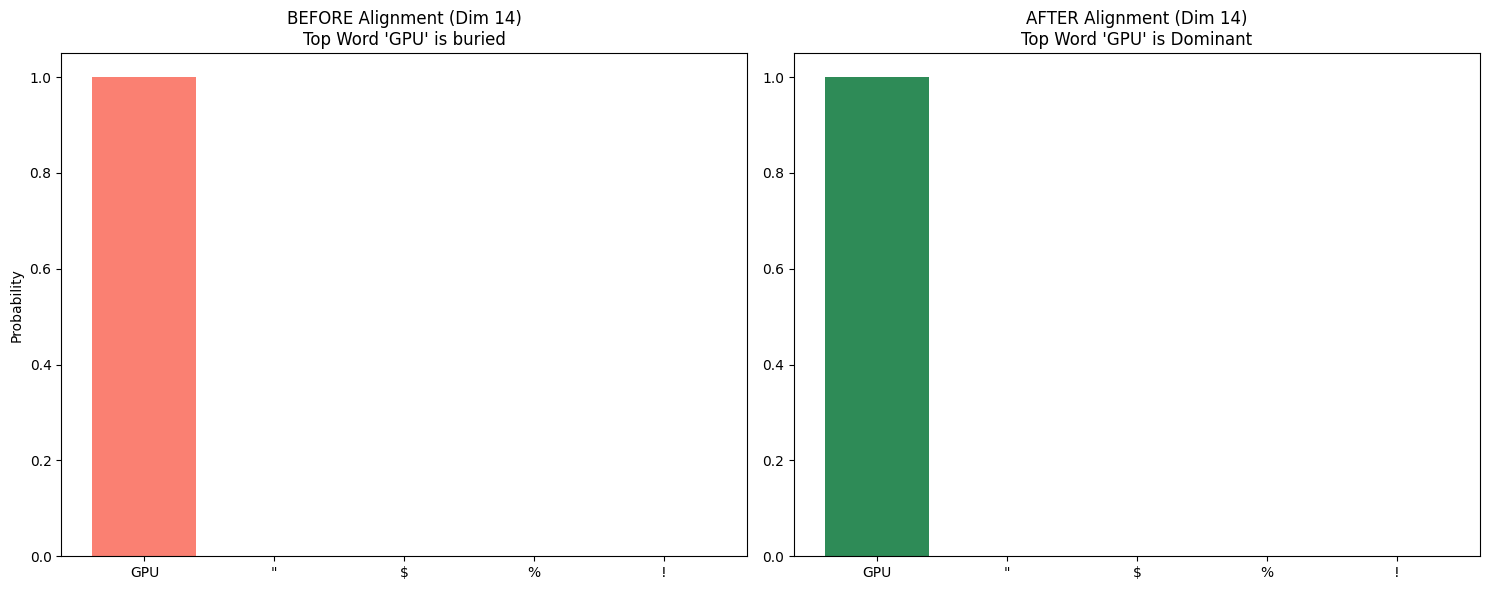

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_alignment(model, tokenizer, dim_index):
    word = master_dict.iloc[dim_index]['Top Word']
    marker_vec = model.embedding.weight[model.V + dim_index]

    # 1. GET BEFORE LOGITS
    with torch.no_grad():
        logits_before = model.fc_out(marker_vec)
        probs_before = torch.softmax(logits_before, dim=-1)
        top_v_b, top_i_b = torch.topk(probs_before, 5)

    # 2. RUN ALIGNMENT
    align_model_heads(model)

    # 3. GET AFTER LOGITS
    with torch.no_grad():
        logits_after = model.fc_out(marker_vec)
        probs_after = torch.softmax(logits_after, dim=-1)
        top_v_a, top_i_a = torch.topk(probs_after, 5)

    # PLOTTING
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot Before
    words_b = [tokenizer.decode([i]) for i in top_i_b]
    ax1.bar(words_b, top_v_b.cpu().numpy(), color='salmon')
    ax1.set_title(f"BEFORE Alignment (Dim {dim_index})\nTop Word '{word}' is buried")
    ax1.set_ylabel("Probability")

    # Plot After
    words_a = [tokenizer.decode([i]) for i in top_i_a]
    ax2.bar(words_a, top_v_a.cpu().numpy(), color='seagreen')
    ax2.set_title(f"AFTER Alignment (Dim {dim_index})\nTop Word '{word}' is Dominant")

    plt.tight_layout()
    plt.show()

# Visualize for Dimension 14 (GPU) or Dimension 7 (Visually)
visualize_alignment(model, tokenizer, dim_index=14)

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# 1. Load a small pretrained model
model_name = "microsoft/phi-2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.float32, device_map="cpu")

def infer_pretrained_dimensions(prompt, layer_idx):
    inputs = tokenizer(prompt, return_tensors="pt")

    # 2. Use a 'Hook' to grab hidden states
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        # Grab the hidden state from the specific layer
        hidden_state = outputs.hidden_states[layer_idx] # Shape: [1, seq_len, 2560]

    # 3. The 'Logit Lens' Projection
    # We use the model's final output layer (lm_head) to decode the hidden layer
    logits = model.lm_head(hidden_state[:, -1, :])

    # 4. Identify the 'Star' concepts firing in this layer
    probs = torch.softmax(logits, dim=-1)
    top_v, top_i = torch.topk(probs, 5)

    print(f"--- Inference at Layer {layer_idx} ---")
    for i in range(5):
        print(f"{tokenizer.decode([top_i[0, i]]):<15} | {top_v[0, i].item()*100:.2f}%")

# Test it out
infer_pretrained_dimensions("The GPU helped the dungeon look", layer_idx=10)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/564M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

def infer_phi_stars(prompt, num_samples=100):
    model.eval()
    all_hidden_states = []

    # 1. Collect activations across a "thought process"
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        # Grab middle layer (Layer 16 is usually the most 'semantic')
        hidden = outputs.hidden_states[16].squeeze(0) # [seq_len, 2560]
        all_hidden_states.append(hidden)

    # 2. Flatten and apply PCA
    data = torch.cat(all_hidden_states, dim=0).cpu().numpy()
    pca = PCA(n_components=50) # Matching your '50 Stars'
    principal_components = pca.fit_transform(data)

    # 3. Project the Top 3 PCA 'Stars' back to vocabulary
    # (Using the Moore-Penrose pseudoinverse of the lm_head)
    components_tensor = torch.tensor(pca.components_, dtype=torch.float32)

    print(f"--- Top Infered Dimensions (Phi-2) ---")
    for i in range(5):
        logits = model.lm_head(components_tensor[i])
        probs = torch.softmax(logits, dim=-1)
        val, idx = torch.topk(probs, 1)
        print(f"PCA Star {i}: {tokenizer.decode(idx)} (Explains {pca.explained_variance_ratio_[i]*100:.2f}% of variance)")

infer_phi_stars("The GPU helped the dungeon look visually impressive with realistic lighting")